# Titanic Survival Analysis & Classification

**Author:** Vishal Shinde

## Project Overview
This notebook performs an end to end analysis of the Titanic dataset. It covers data inspection, descriptive statistics, missing-value analysis, exploratory data analysis (EDA), preprocessing, classification using Gaussian Naive Bayes and K-Nearest Neighbours (KNN) and model evaluation.

### Skills Demonstrated
- Python, Pandas and NumPy
- Exploratory Data Analysis (EDA)
- Data cleaning and missing-value treatment
- One-hot encoding and feature scaling
- Train/test splitting
- Classification with Gaussian Naive Bayes and KNN
- Confusion matrices and classification metrics
- Model comparison and interpretation

> **GitHub note:** Keep `Titanic-Dataset.csv` in the same repository folder as this notebook so the data-loading cell works.

In [1]:
# Essential Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Train/Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Classification Models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

# Professional preprocessing workflow
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
# Q1.) Reading The Data And Descriptive Statistics

data_titanic = pd.read_csv("Titanic-Dataset.csv")

data_titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
# Dataset Metadata

print("Dataset information:")
data_titanic.info()

print("\nDescriptive statistics:")
display(data_titanic.describe())

print("\nDataset shape:", data_titanic.shape)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Descriptive statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Dataset shape: (891, 12)


In [4]:
#Checking for Missing Values

print("\nMissing Values:")
print(data_titanic.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# Frequency Distribution

print("Sex:")
print(data_titanic["Sex"].value_counts())

print("\nPclass:")
print(data_titanic["Pclass"].value_counts())

print("\nEmbarked:")
print(data_titanic["Embarked"].value_counts())

print("\nSurvived:")
print(data_titanic["Survived"].value_counts())

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Survived:
Survived
0    549
1    342
Name: count, dtype: int64


In [6]:
# Percentage Distribution

print("\nSurvival Percentage:")
print(data_titanic["Survived"].value_counts(normalize=True) * 100)


Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


## Exploratory Data Analysis (EDA)

Before building models, we inspect the main patterns in the data. The visualizations below help identify class imbalance, demographic patterns, distributions, and relationships that may be useful for prediction.

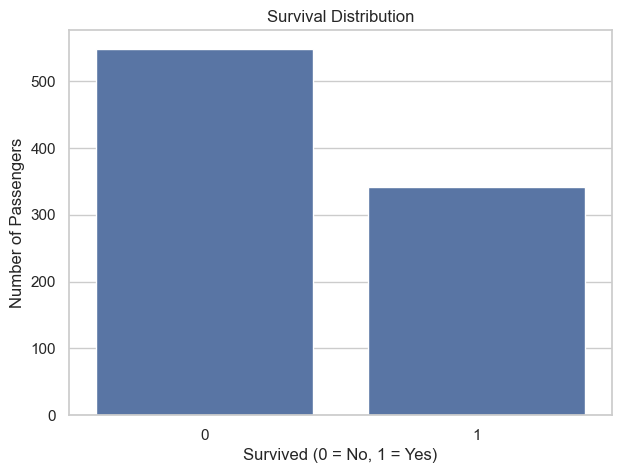

In [ ]:
# 1. Survival Distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=data_titanic, x="Survived")
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

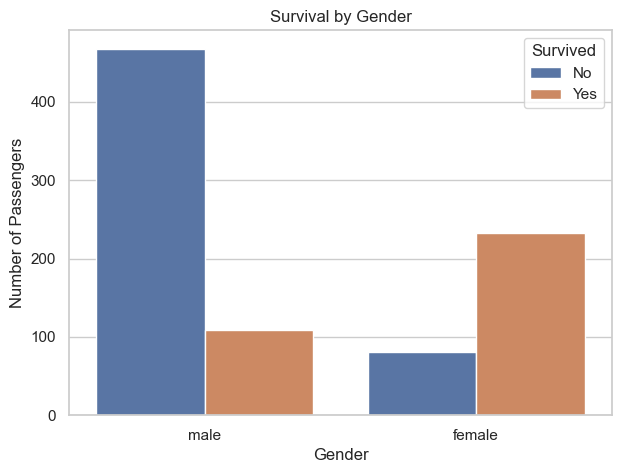

In [ ]:
# 2. Survival by Gender

plt.figure(figsize=(7, 5))
sns.countplot(data=data_titanic, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

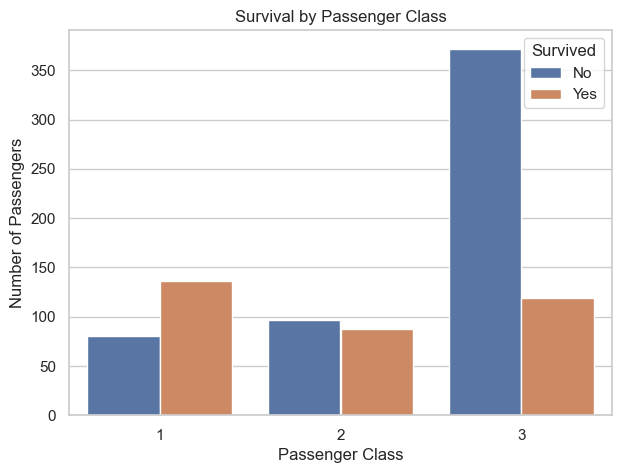

In [ ]:
# 3. Survival by Passenger Class

plt.figure(figsize=(7, 5))
sns.countplot(data=data_titanic, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

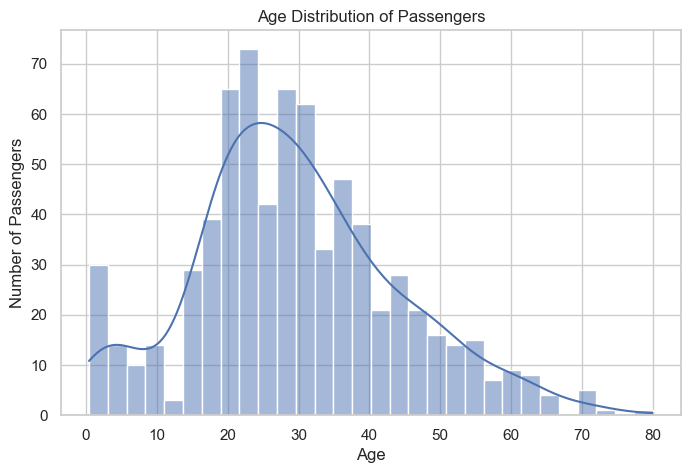

In [ ]:
# 4. Age Distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=data_titanic, x="Age", bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

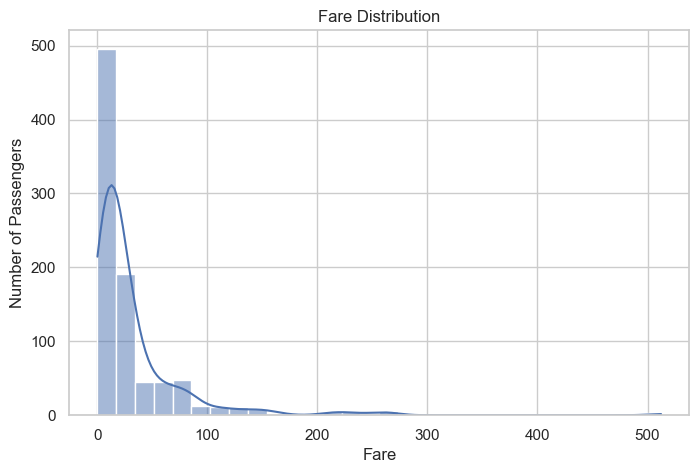

In [ ]:
# 5. Fare Distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=data_titanic, x="Fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

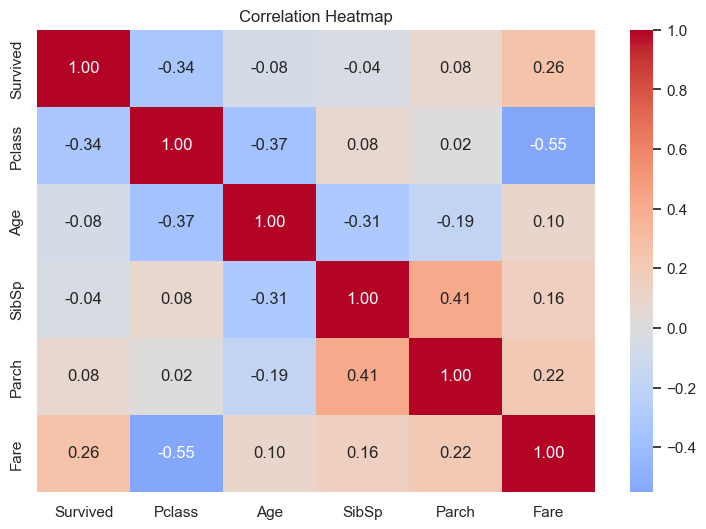

In [ ]:
# 6. Correlation Heatmap for Numerical Variables

plt.figure(figsize=(9, 6))
numeric_for_corr = data_titanic[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### EDA Takeaways


- What proportion of passengers survived?
- How does survival differ by gender?
- How does survival differ across passenger classes?
- Are there missing values that require treatment before modelling?
- Which numerical variables show noticeable relationships with survival?

In [ ]:
# Data Driven EDA Summary

survival_rate = data_titanic["Survived"].mean() * 100
missing_age = data_titanic["Age"].isna().sum()
missing_embarked = data_titanic["Embarked"].isna().sum()

print(f"Overall survival rate: {survival_rate:.2f}%")
print(f"Missing Age values: {missing_age}")
print(f"Missing Embarked values: {missing_embarked}")

print("\nSurvival rate by gender (%):")
display((data_titanic.groupby("Sex")["Survived"].mean() * 100).round(2).to_frame("Survival Rate"))

print("Survival rate by passenger class (%):")
display((data_titanic.groupby("Pclass")["Survived"].mean() * 100).round(2).to_frame("Survival Rate"))

Overall survival rate: 38.38%
Missing Age values: 177
Missing Embarked values: 2

Survival rate by gender (%):


,Survival Rate
Sex,
female,74.20
male,18.89


Survival rate by passenger class (%):


,Survival Rate
Pclass,
1,62.96
2,47.28
3,24.24


In [14]:
# Q2.) Defining The Target and Predictors

y = data_titanic["Survived"]
X = data_titanic[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"
    ]
]
print(X.head())
print(y.head())

   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [15]:
# Q2.) Train And Test Split 80:20

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [16]:
# Numerical Columns

numerical_cols = [
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]
print(numerical_cols)

# Categorical Columns

categorical_cols = [
    "Pclass",
    "Sex",
    "Embarked"
]
print(categorical_cols)

['Age', 'SibSp', 'Parch', 'Fare']
['Pclass', 'Sex', 'Embarked']


In [17]:
# Q3.) a.) Replacing Missing Numerical Values With Median Categoric With Most Frequent Using Simple Imputer

num_imputer = SimpleImputer(strategy="median")

X_train[["Age", "Fare"]] = num_imputer.fit_transform(
    X_train[["Age", "Fare"]]
)

# Q3.) b.) Replacing Missing Categoric Values With Most Frequent Using Simple Imputer

cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[["Sex", "Embarked"]] = cat_imputer.fit_transform(
    X_train[["Sex", "Embarked"]]
)

In [18]:
# Q3.) c.) Encoding Pclass, Sex and Embarked using one-hot encoding

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

x_train_encoded = encoder.fit_transform(
    X_train[["Pclass", "Sex", "Embarked"]]
)

In [19]:
# Q3.) d.) Standardise the numerical predictors

scaler = StandardScaler()

X_train[["Age", "SibSp", "Parch", "Fare"]] = scaler.fit_transform(
    X_train[["Age", "SibSp", "Parch", "Fare"]]
)

In [20]:
# Q3.) e.) Fitting the preprocessing methods on the training data and use them to transform the testing data

X_test[["Age", "Fare"]] = num_imputer.transform(
    X_test[["Age", "Fare"]]
)

X_test[["Sex", "Embarked"]] = cat_imputer.transform(
    X_test[["Sex", "Embarked"]]
)

x_test_encoded = encoder.transform(
    X_test[["Pclass", "Sex", "Embarked"]]
)

X_test[["Age", "SibSp", "Parch", "Fare"]] = scaler.transform(
    X_test[["Age", "SibSp", "Parch", "Fare"]]
)

x_train_final = np.hstack((
    X_train[["Age", "SibSp", "Parch", "Fare"]].values,
    x_train_encoded
))

x_test_final = np.hstack((
    X_test[["Age", "SibSp", "Parch", "Fare"]].values,
    x_test_encoded
))

In [21]:
# Q4.) Gaussian Naïve Bayes Model 

nb_model = GaussianNB()

nb_model.fit(x_train_final, y_train)

y_pred_nb = nb_model.predict(x_test_final)

# Naive Bayesian Confusion Matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix:")
print(cm_nb)

Confusion Matrix:
[[81 24]
 [17 57]]


In [22]:
# Q5.) KNN Model with k=3 

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(x_train_final, y_train)

y_pred_knn = knn_model.predict(x_test_final)

# KNN Confusion Matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("Confusion Matrix:")
print(cm_knn)

Confusion Matrix:
[[90 15]
 [21 53]]


In [23]:
# Q6.) Gaussian Naive Bayes Evaluation

tn, fp, fn, tp = cm_nb.ravel()

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
specificity_nb = tn / (tn + fp)
f1_nb = f1_score(y_test, y_pred_nb)

print("Accuracy:", accuracy_nb * 100, "%")
print("Precision:", precision_nb * 100, "%")
print("Recall:", recall_nb * 100, "%")
print("Specificity:", specificity_nb * 100, "%")
print("F1 Score:", f1_nb * 100, "%")

Accuracy: 77.09497206703911 %
Precision: 70.37037037037037 %
Recall: 77.02702702702703 %
Specificity: 77.14285714285715 %
F1 Score: 73.54838709677419 %


In [24]:
# KNN Evaluation

tn, fp, fn, tp = cm_knn.ravel()

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
specificity_knn = tn / (tn + fp)
f1_knn = f1_score(y_test, y_pred_knn)

print("Accuracy:", accuracy_knn * 100, "%")
print("Precision:", precision_knn * 100, "%")
print("Recall:", recall_knn * 100, "%")
print("Specificity:", specificity_knn * 100, "%")
print("F1 Score:", f1_knn * 100, "%")

Accuracy: 79.88826815642457 %
Precision: 77.94117647058823 %
Recall: 71.62162162162163 %
Specificity: 85.71428571428571 %
F1 Score: 74.64788732394366 %


In [25]:
# Comparison Table

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score"],
    "Gaussian NB": [
        accuracy_nb * 100,
        precision_nb * 100,
        recall_nb * 100,
        specificity_nb * 100,
        f1_nb * 100
    ],
    "KNN (k=3)": [
        accuracy_knn * 100,
        precision_knn * 100,
        recall_knn * 100,
        specificity_knn * 100,
        f1_knn * 100
    ]
})

comparison

,Metric,Gaussian NB,KNN (k=3)
0,Accuracy,77.094972,79.888268
1,Precision,70.370370,77.941176
2,Recall,77.027027,71.621622
3,Specificity,77.142857,85.714286
4,F1 Score,73.548387,74.647887


In [26]:
# Better Performing Model

if accuracy_nb > accuracy_knn:
    print("Better Performing Model: Gaussian Naive Bayes")
elif accuracy_knn > accuracy_nb:
    print("Better Performing Model: KNN (k=3)")
else:
    print("Both Models Have The Same Accuracy")

Better Performing Model: KNN (k=3)


# Insights

# 1. KNN achieved higher accuracy, precision, specificity, and F1-score than Gaussian Naïve Bayes, while Gaussian Naïve Bayes achieved higher recall.

# 2. The preprocessing steps such as handling missing values, One-Hot Encoding, and feature scaling prepared the Titanic dataset for classification using both models.

In [ ]:
# Re-create the raw predictors so the pipeline starts from untouched data

X_raw = data_titanic[[
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"
]].copy()
y_raw = data_titanic["Survived"].copy()

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

print("Training data:", X_train_pipe.shape)
print("Testing data:", X_test_pipe.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [ ]:
# Define preprocessing

numerical_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            categorical_features
        )
    ]
)

In [ ]:
# Gaussian Naive Bayes pipeline

nb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GaussianNB())
])

nb_pipeline.fit(X_train_pipe, y_train_pipe)
y_pred_nb_pipe = nb_pipeline.predict(X_test_pipe)

In [ ]:
# KNN pipeline

knn_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=3))
])

knn_pipeline.fit(X_train_pipe, y_train_pipe)
y_pred_knn_pipe = knn_pipeline.predict(X_test_pipe)

In [ ]:
# Evaluation Helper

def evaluate_model(name, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Specificity": tn / (tn + fp),
        "F1 Score": f1_score(y_true, y_pred)
    }

portfolio_results = pd.DataFrame([
    evaluate_model("Gaussian Naive Bayes", y_test_pipe, y_pred_nb_pipe),
    evaluate_model("KNN (k=3)", y_test_pipe, y_pred_knn_pipe)
])

portfolio_results.set_index("Model").style.format("{:.2%}")

,Accuracy,Precision,Recall,Specificity,F1 Score
Model,,,,,
Gaussian Naive Bayes,77.65%,71.64%,69.57%,82.73%,70.59%
KNN (k=3),82.68%,78.79%,75.36%,87.27%,77.04%


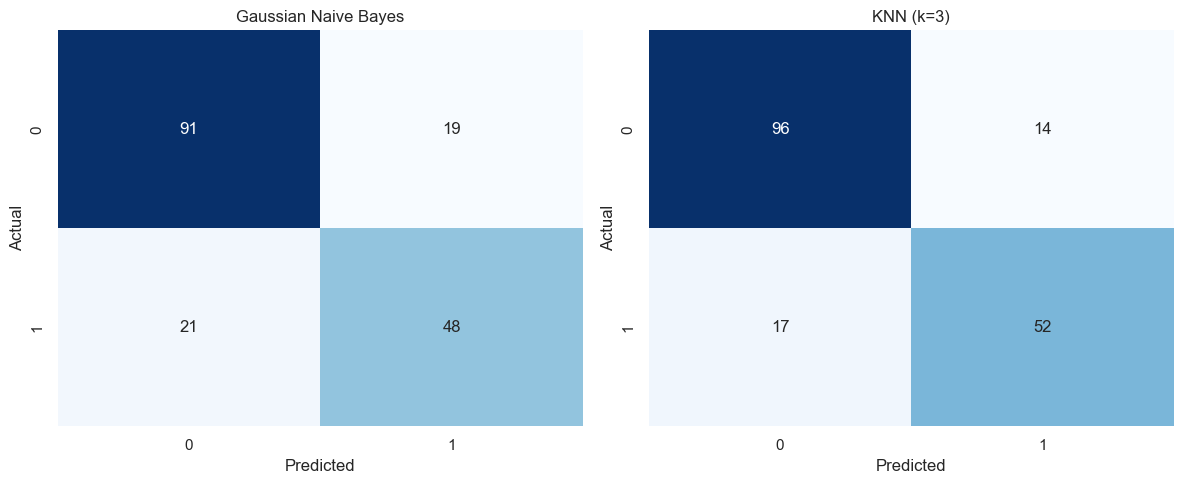

In [ ]:
# Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(y_test_pipe, y_pred_nb_pipe),
    annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0]
)
axes[0].set_title("Gaussian Naive Bayes")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test_pipe, y_pred_knn_pipe),
    annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1]
)
axes[1].set_title("KNN (k=3)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
# Classification Reports

print("Gaussian Naive Bayes Classification Report")
print(classification_report(y_test_pipe, y_pred_nb_pipe))

print("KNN (k=3) Classification Report")
print(classification_report(y_test_pipe, y_pred_knn_pipe))

Gaussian Naive Bayes Classification Report
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.72      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179

KNN (k=3) Classification Report
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       110
           1       0.79      0.75      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



## Model Interpretation

Model comparison should depend on the metric that matters for the problem rather than accuracy alone.

- **Accuracy:** overall proportion of correct predictions.
- **Precision:** among passengers predicted to survive, how many actually survived.
- **Recall:** among passengers who actually survived, how many were correctly identified.
- **Specificity:** among passengers who did not survive, how many were correctly identified as non-survivors.
- **F1 Score:** harmonic mean of precision and recall.

For this dataset, the two models can therefore be discussed in terms of their trade-offs rather than simply saying that one metric makes a model universally better.

In [ ]:
# Automatic metric-based interpretation

results_numeric = portfolio_results.set_index("Model")
for metric in ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score"]:
    best_model = results_numeric[metric].idxmax()
    print(f"Highest {metric}: {best_model} ({results_numeric.loc[best_model, metric]:.2%})")

Highest Accuracy: KNN (k=3) (82.68%)
Highest Precision: KNN (k=3) (78.79%)
Highest Recall: KNN (k=3) (75.36%)
Highest Specificity: KNN (k=3) (87.27%)
Highest F1 Score: KNN (k=3) (77.04%)



1. **Why was missing data handled?** Missing values can cause errors or reduce the usable training data. Median imputation is used for numerical features and most-frequent imputation for categorical features.
2. **Why one-hot encode categorical variables?** Machine-learning models require numerical representations; one-hot encoding converts categories into separate binary features.
3. **Why standardize numerical features?** KNN relies on distances, so features with larger numerical scales could otherwise dominate the distance calculation.
4. **Why use a train/test split?** The test set provides an estimate of how the trained model performs on unseen data.
5. **Why use a Pipeline?** It keeps preprocessing tied to the model and ensures the same transformations are applied consistently.
6. **Why compare multiple metrics?** Accuracy alone can hide differences in false positives and false negatives.
7. **Why compare Naive Bayes and KNN?** They make predictions using different principles: Naive Bayes is probabilistic, while KNN uses distances to neighbouring observations.

### Important limitation
This is a small educational dataset. The results should be treated as an exercise in analytics and classification rather than evidence that the models will generalize to a different population or real-world deployment.